In [6]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score,precision_score, recall_score, f1_score,confusion_matrix


In [7]:
df=pd.read_csv(r"E:\PYTHON\Breast cancer prediction\Breast cancer prediction\breast-cancer.csv")

In [8]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
df.drop(['id'], axis=1, inplace=True, errors='ignore')

In [10]:
df.tail()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [11]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [13]:
df.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [14]:
print('Total duplicate value : ',df.duplicated().sum())

Total duplicate value :  0


<Axes: xlabel='diagnosis', ylabel='count'>

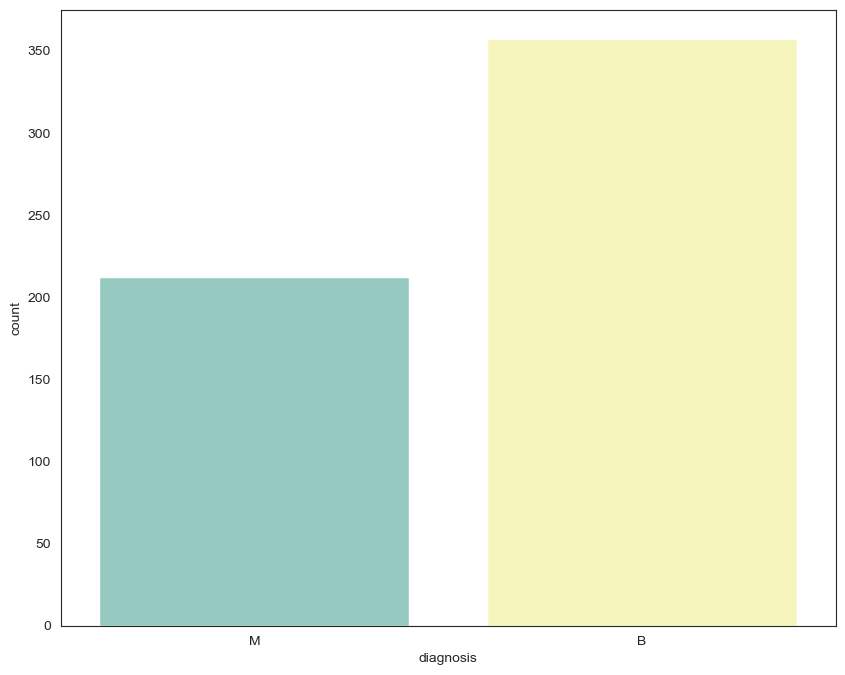

In [15]:
sns.set_style("white")
sns.set_context({"figure.figsize": (10, 8)})
sns.countplot(x=df['diagnosis'],label='Count',palette="Set3")

In [16]:
df_mean=df.iloc[:,1:11]
df_se=df.iloc[:,11:22]
df_worst=df.iloc[:,23:]

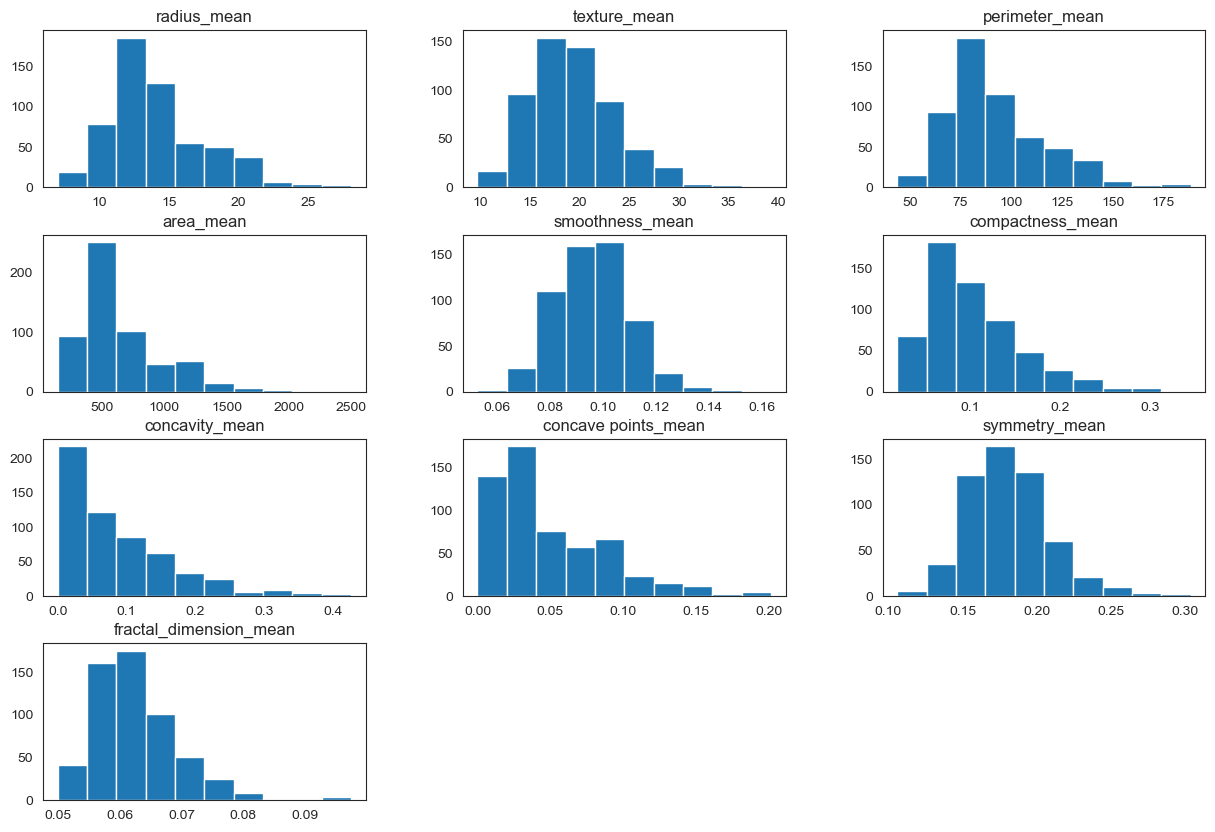

In [17]:
hist_mean=df_mean.hist(bins=10,figsize=(15,10),grid=False)

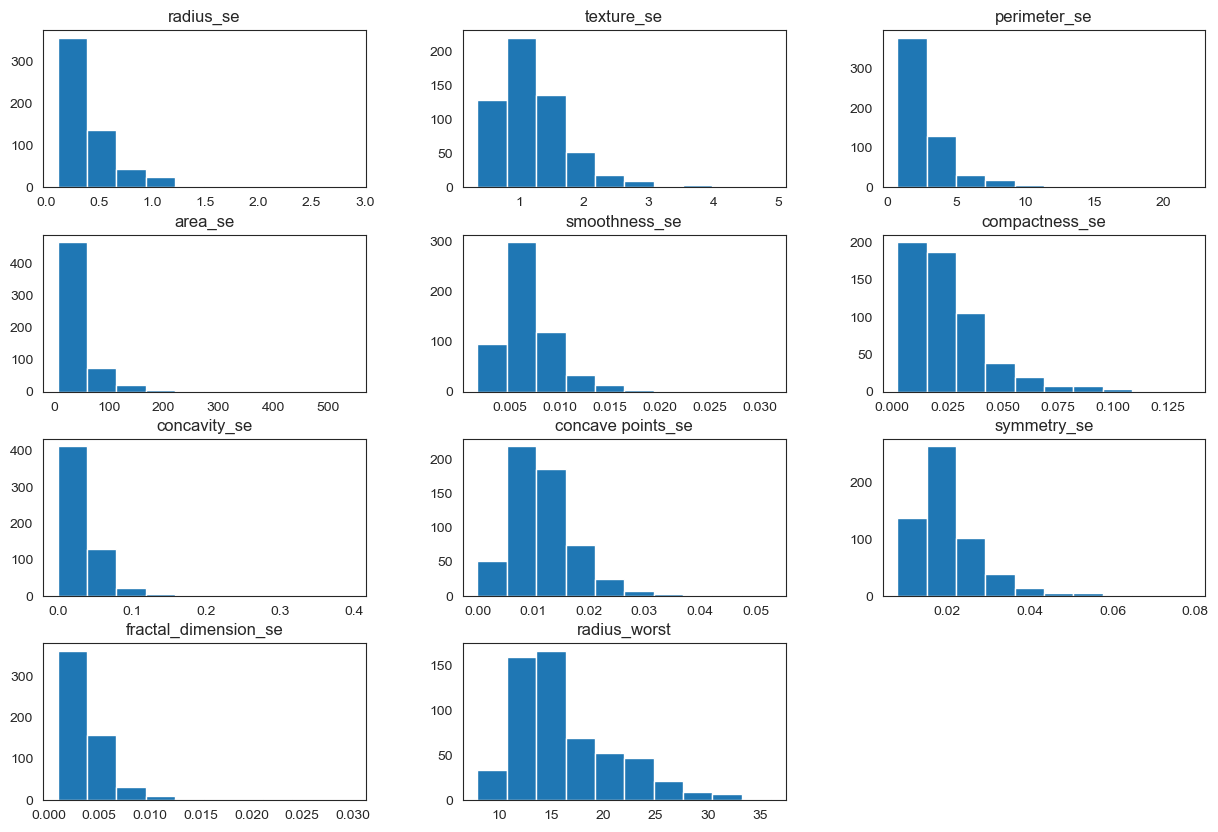

In [18]:
hist_se=df_se.hist(bins=10, figsize=(15, 10),grid=False,)


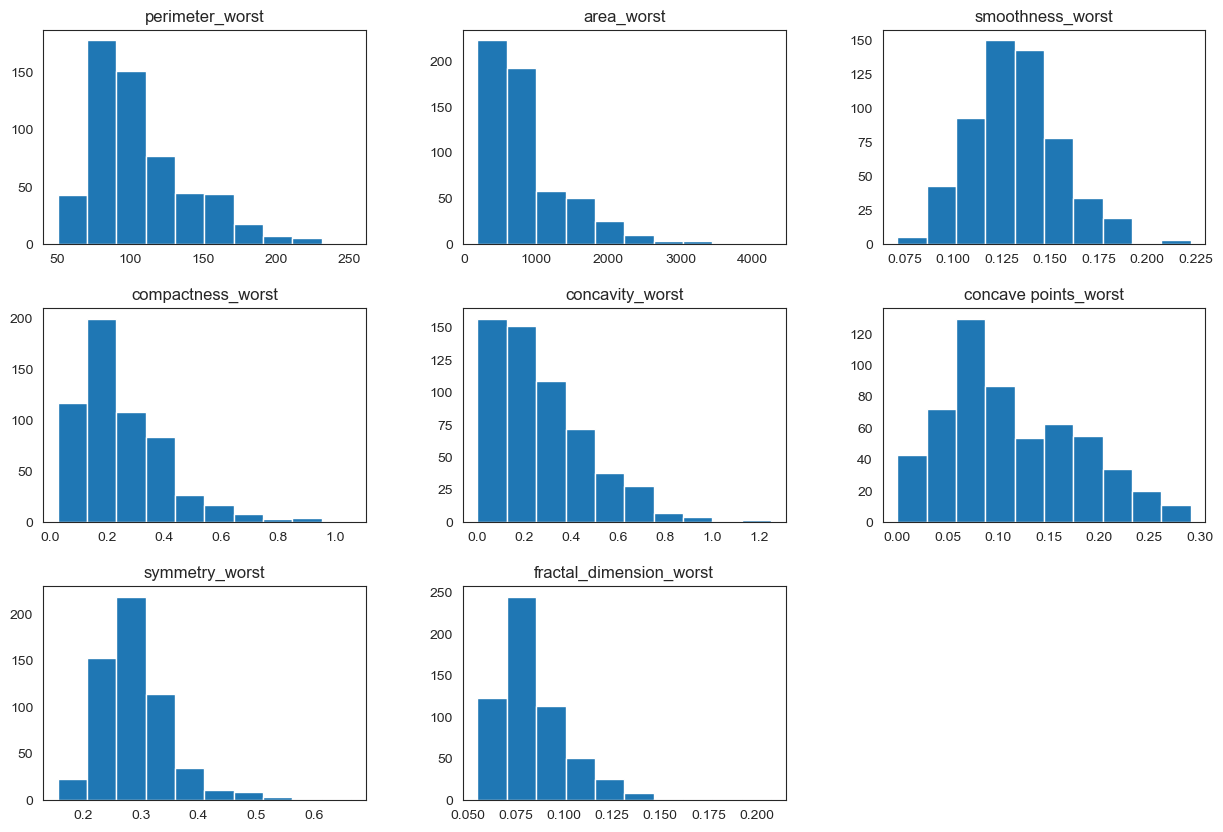

In [19]:
hist_worst=df_worst.hist(bins=10,figsize=(15,10),grid=False)

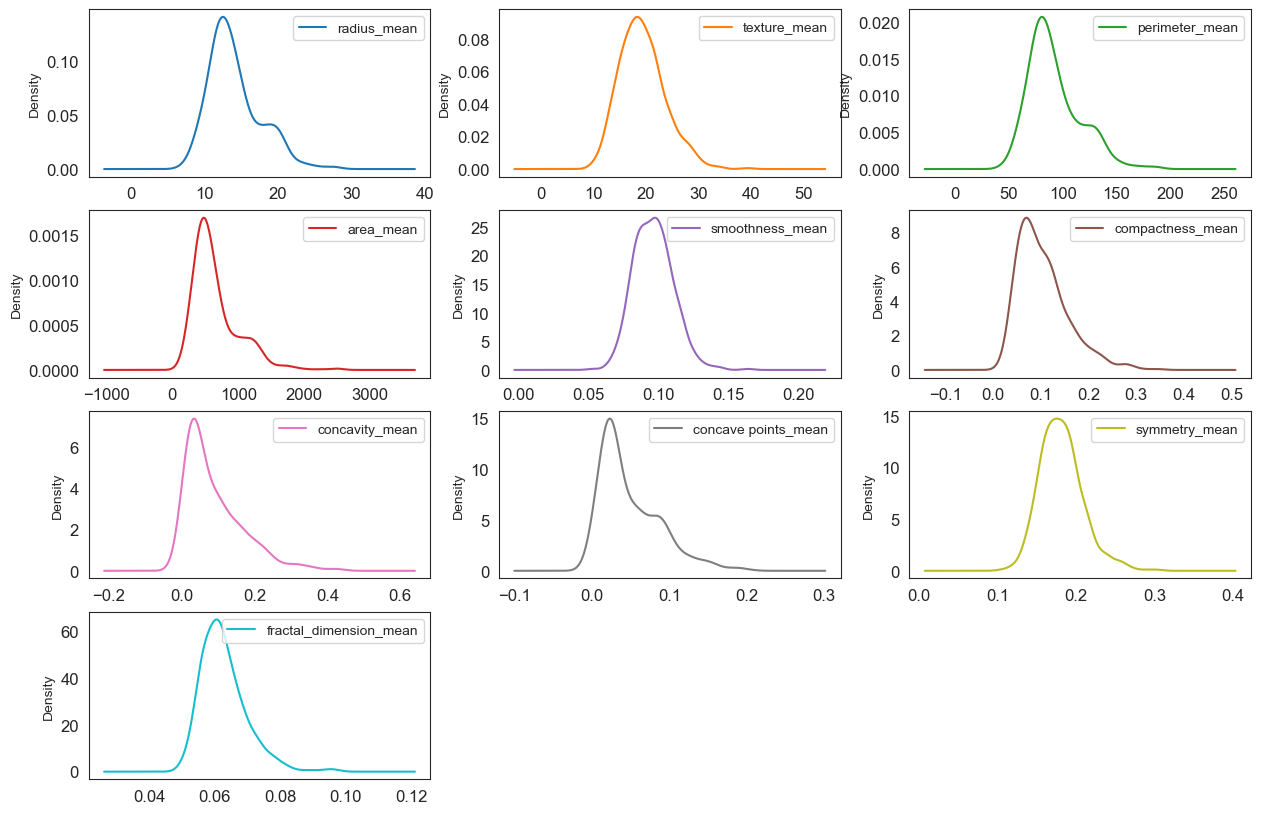

In [20]:
plt = df_mean.plot(kind= 'density', subplots=True,layout=(4,3), sharex=False, 
                     sharey=False, fontsize=12, figsize=(15,10))

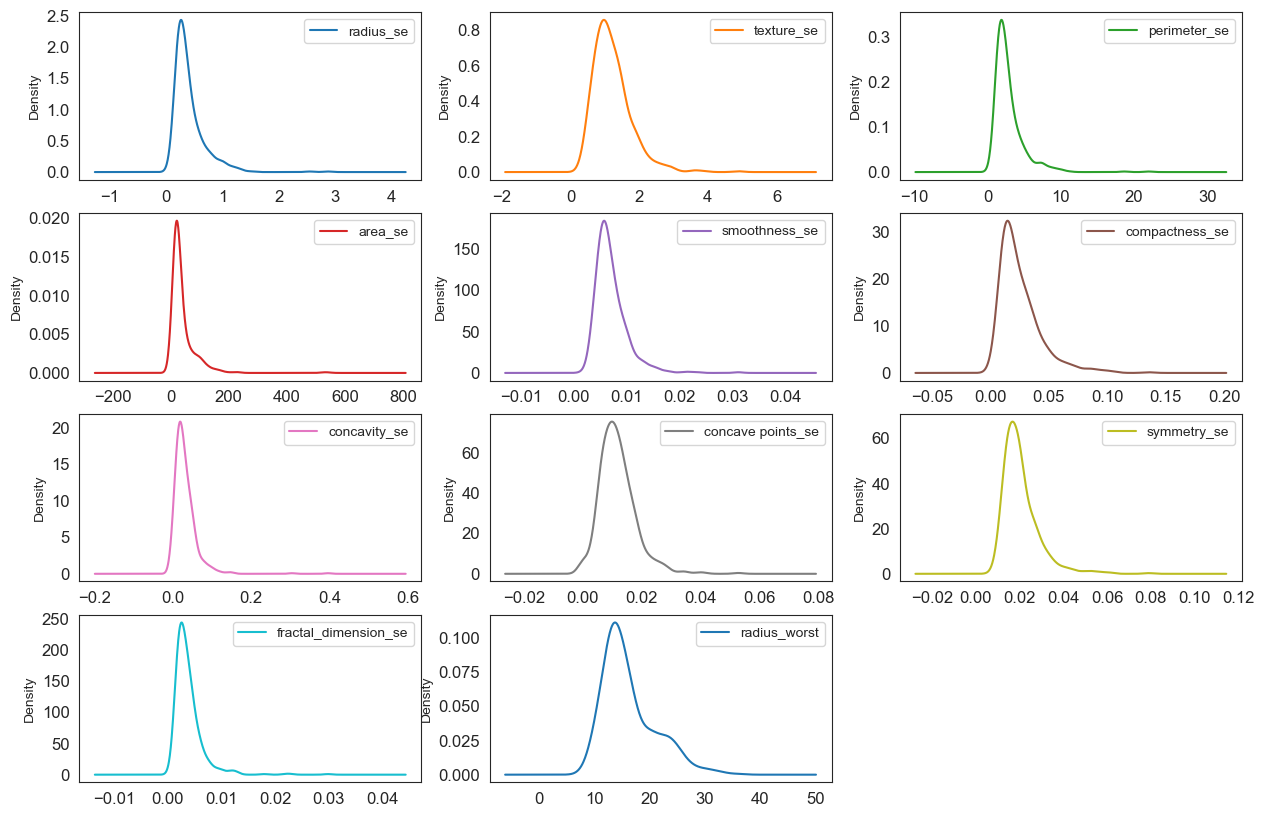

In [21]:
plt = df_se.plot(kind= 'density', subplots=True,layout=(4,3), sharex=False, 
                     sharey=False, fontsize=12, figsize=(15,10))

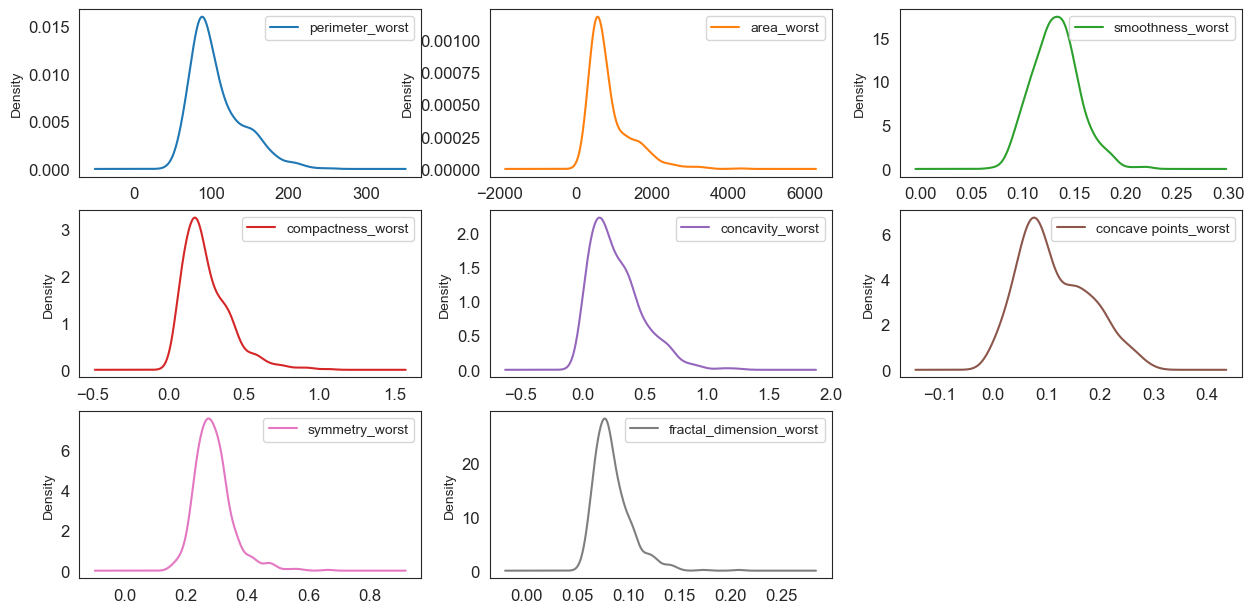

In [22]:
plt = df_worst.plot(kind= 'density', subplots=True,layout=(4,3), sharex=False, 
                     sharey=False, fontsize=12, figsize=(15,10))

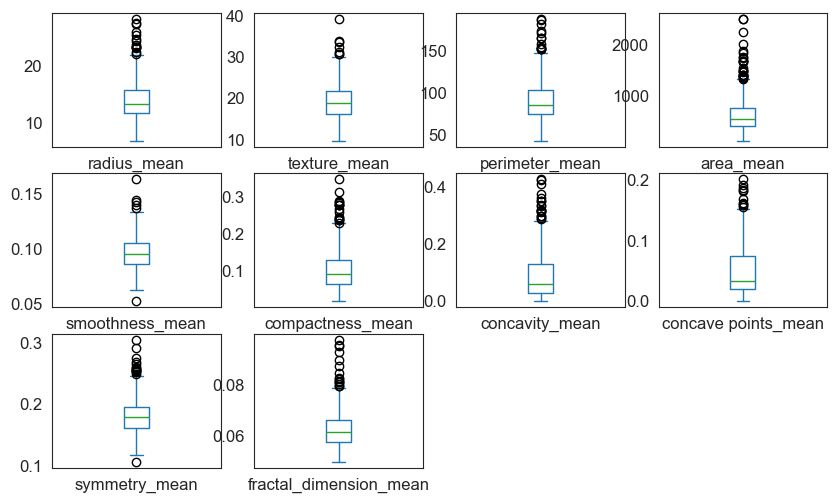

In [23]:
plt=df_mean.plot(kind= 'box' , subplots=True, layout=(4,4), sharex=False, sharey=False,
                 fontsize=12)

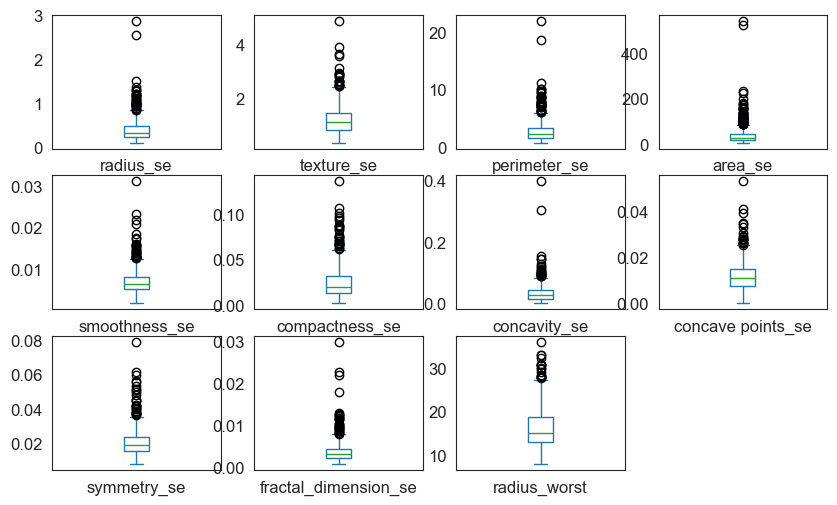

In [24]:
plt=df_se.plot(kind= 'box' , subplots=True, layout=(4,4), sharex=False, sharey=False,
                 fontsize=12)

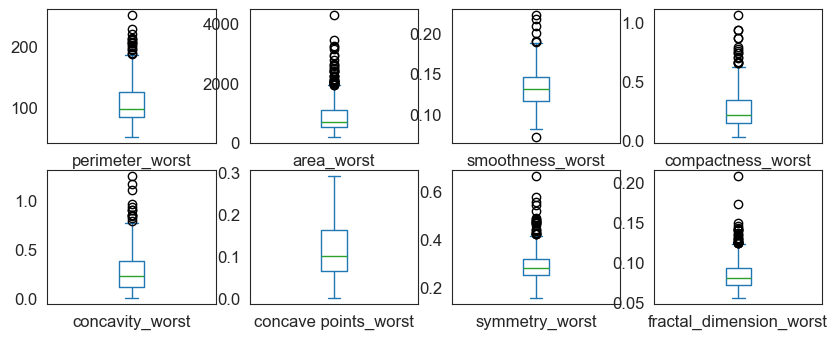

In [25]:
plt=df_worst.plot(kind= 'box' , subplots=True, layout=(4,4), sharex=False, sharey=False,
                 fontsize=12)

In [26]:
X=df.drop(['diagnosis'],axis=1)
y=df['diagnosis']

In [27]:
le = LabelEncoder()
y = le.fit_transform(y)

In [28]:
scaler =StandardScaler()
X_scaler= scaler.fit_transform(X)

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X_scaler,y,test_size=.3,random_state=42)


In [30]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [31]:
lr.score(X_test,y_test)

0.9824561403508771

In [32]:
preducation = lr.predict(X_test)
preducation[:10]

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0])

In [33]:
accuracy = accuracy_score(y_test,preducation)
precision = precision_score(y_test,preducation)
recall = recall_score(y_test,preducation)
f1 = f1_score(y_test,preducation)
print("Logistic Regression Model Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Logistic Regression Model Results:
Accuracy: 0.9824561403508771
Precision: 0.96875
Recall: 0.9841269841269841
F1 Score: 0.9763779527559056


<Axes: >

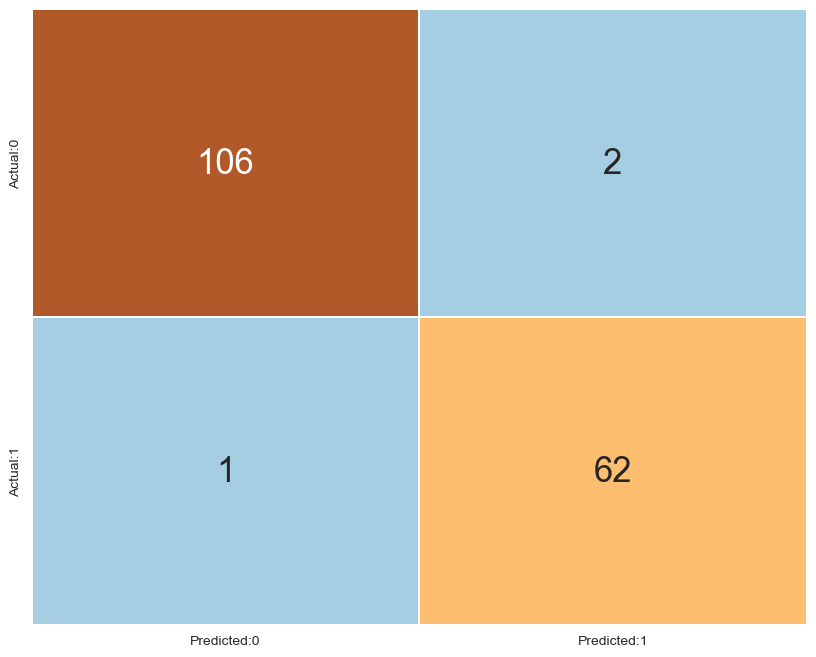

In [34]:
cm=confusion_matrix(y_test,preducation)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Paired', cbar = False,linewidths = 0.1, annot_kws = {'size':25})


<Axes: ylabel='Density'>

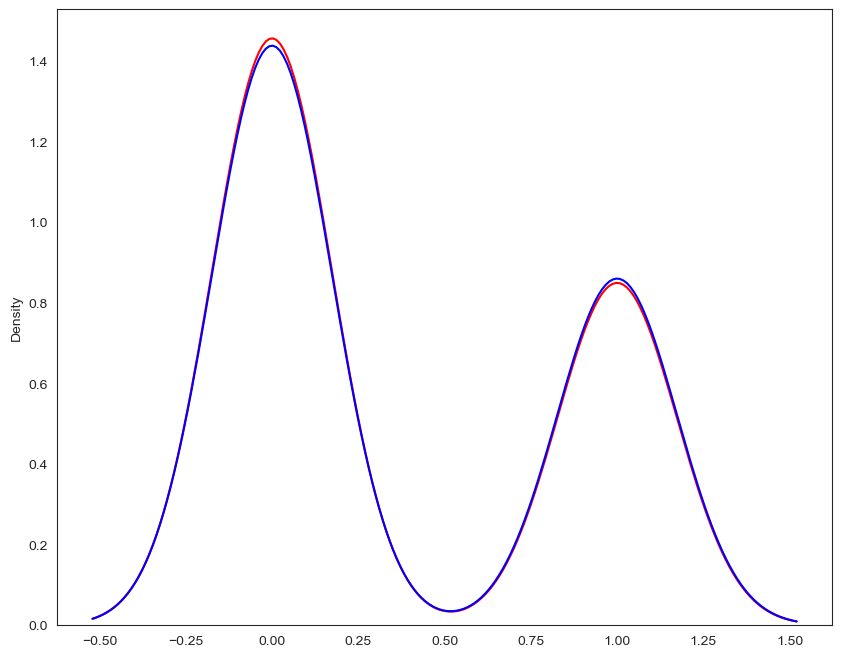

In [35]:
ax1=sns.distplot(y_test,color='r',hist=False,label='Acual value')
sns.distplot(preducation,color='b',hist=False,label='preducation',ax=ax1)


In [36]:
rfc=RandomForestClassifier()

In [37]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [38]:
rfc.score(X_test,y_test)

0.9649122807017544

In [39]:
preducation=rfc.predict(X_test)

In [40]:
accuracy = accuracy_score(y_test,preducation)
precision = precision_score(y_test,preducation)
recall = recall_score(y_test,preducation)
f1 = f1_score(y_test,preducation)
print("RandomForestClassifier Model Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

RandomForestClassifier Model Results:
Accuracy: 0.9649122807017544
Precision: 0.9672131147540983
Recall: 0.9365079365079365
F1 Score: 0.9516129032258065


<Axes: >

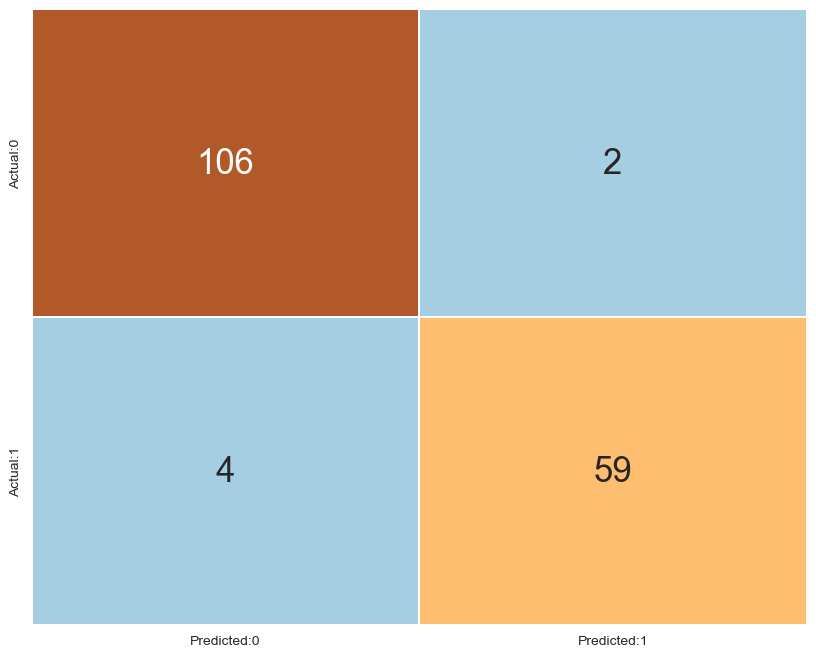

In [41]:
cm=confusion_matrix(y_test,preducation)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Paired', cbar = False,linewidths = 0.1, annot_kws = {'size':25})


<Axes: ylabel='Density'>

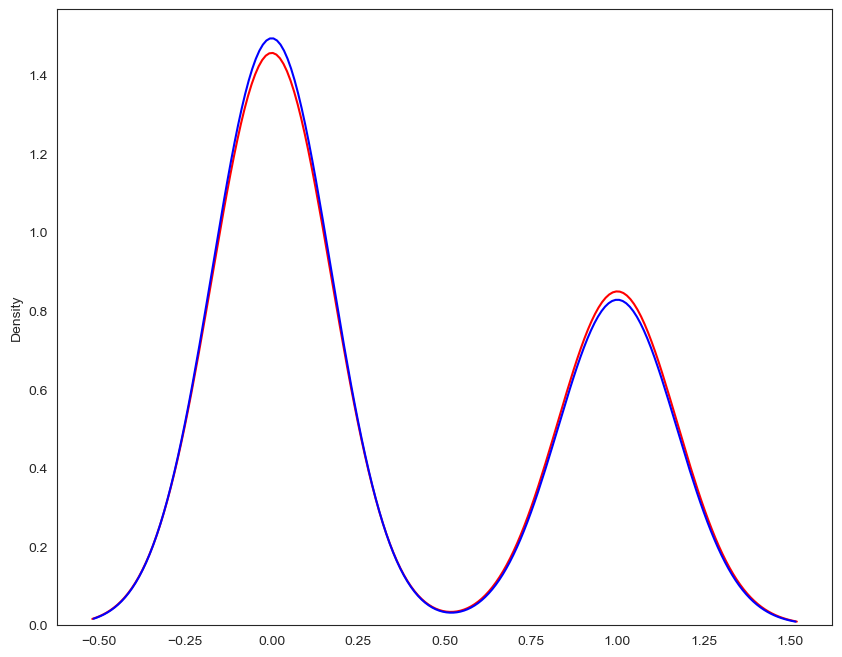

In [42]:
ax1=sns.distplot(y_test,color='r',hist=False,label='Acual value')
sns.distplot(preducation,color='b',hist=False,label='preducation',ax=ax1)


In [43]:
sv=SVC(kernel='linear', random_state = 10)

In [44]:
sv.fit(X_train,y_train)

SVC(kernel='linear', random_state=10)

In [45]:
sv.score(X_test,y_test)

0.9766081871345029

In [46]:
preducation=sv.predict(X_test)

In [47]:
accuracy = accuracy_score(y_test,preducation)
precision = precision_score(y_test,preducation)
recall = recall_score(y_test,preducation)
f1 = f1_score(y_test,preducation)
print("Support Vector Machine Model Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Support Vector Machine Model Results:
Accuracy: 0.9766081871345029
Precision: 0.9682539682539683
Recall: 0.9682539682539683
F1 Score: 0.9682539682539683


<Axes: >

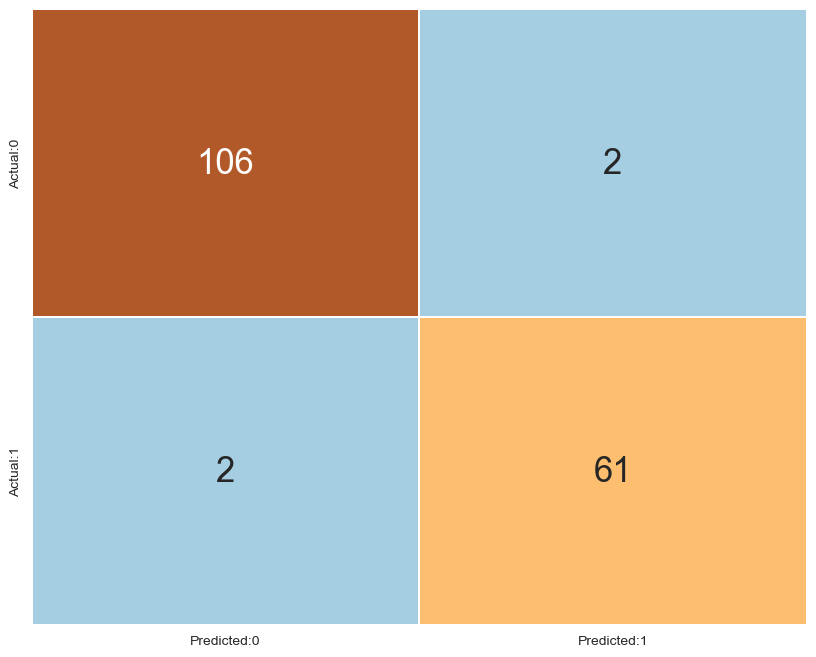

In [48]:
cm=confusion_matrix(y_test,preducation)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Paired', cbar = False,linewidths = 0.1, annot_kws = {'size':25})


<Axes: ylabel='Density'>

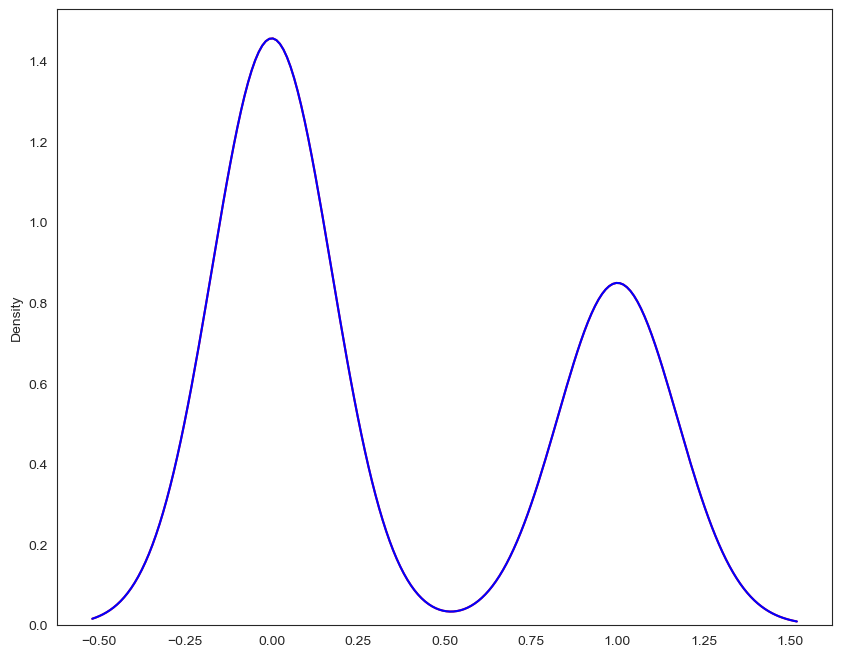

In [49]:
ax1=sns.distplot(y_test,color='r',hist=False,label='Acual value')
sns.distplot(preducation,color='b',hist=False,label='preducation',ax=ax1)


In [50]:
DT=DecisionTreeClassifier()

In [51]:
DT.fit(X_train,y_train)

DecisionTreeClassifier()

In [52]:
DT.score(X_test,y_test)

0.9298245614035088

In [53]:
preducation=DT.predict(X_test)

In [54]:
accuracy = accuracy_score(y_test,preducation)
precision = precision_score(y_test,preducation)
recall = recall_score(y_test,preducation)
f1 = f1_score(y_test,preducation)
print("DecisionTreeClassifier Model Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

DecisionTreeClassifier Model Results:
Accuracy: 0.9298245614035088
Precision: 0.8923076923076924
Recall: 0.9206349206349206
F1 Score: 0.90625


<Axes: >

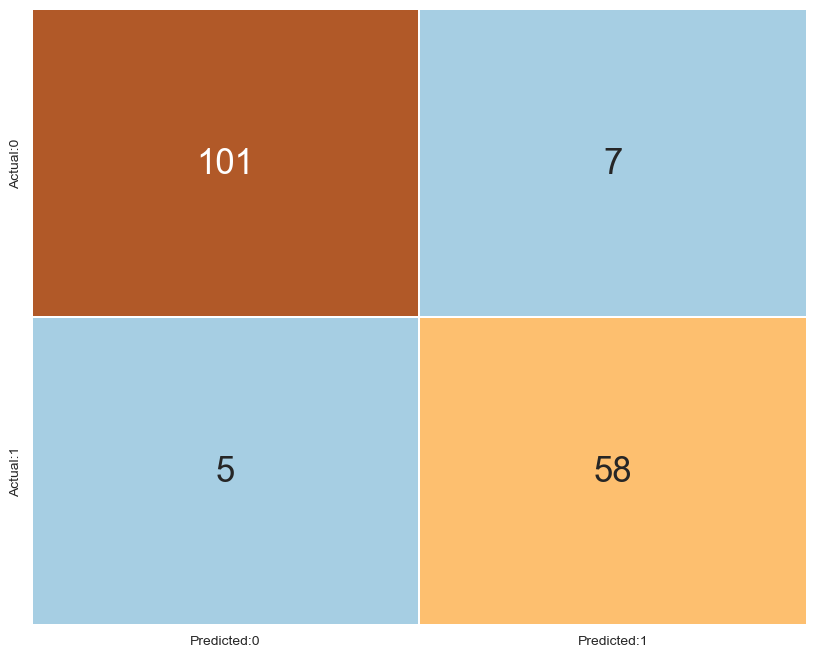

In [55]:
cm=confusion_matrix(y_test,preducation)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Paired', cbar = False,linewidths = 0.1, annot_kws = {'size':25})


<Axes: ylabel='Density'>

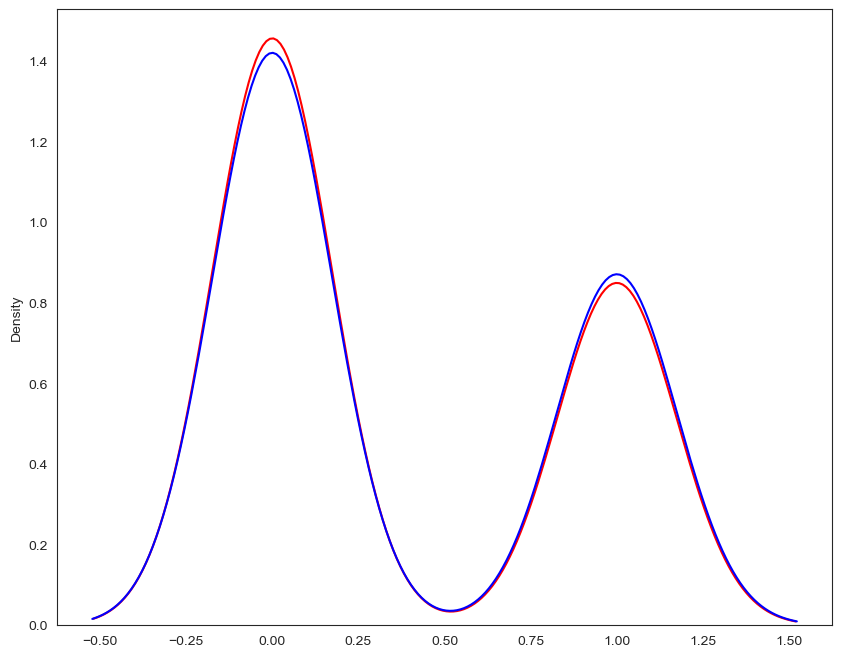

In [56]:
ax1=sns.distplot(y_test,color='r',hist=False,label='Acual value')
sns.distplot(preducation,color='b',hist=False,label='preducation',ax=ax1)


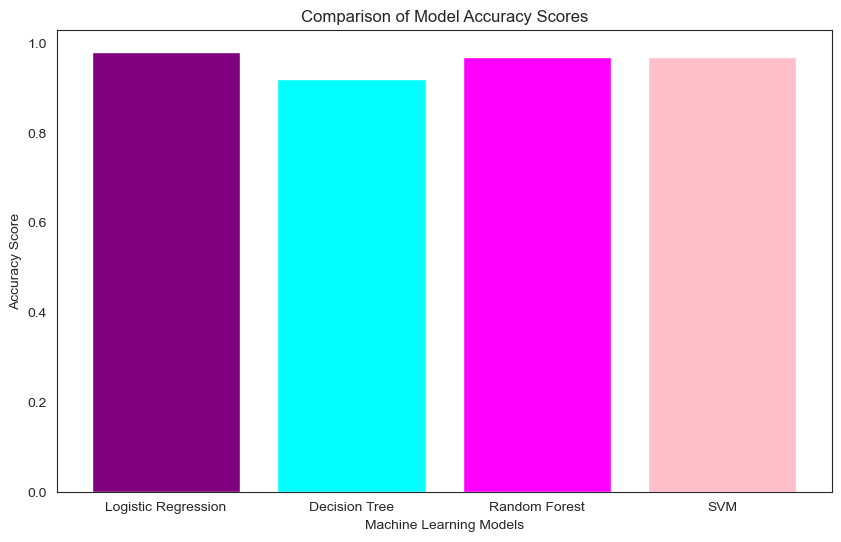

In [57]:
import matplotlib.pyplot as plt

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']
accuracy_scores = [0.98, 0.92, 0.97, 0.97]
colors = ['purple', 'cyan', 'magenta', 'pink']

plt.figure(figsize=(10, 6))

plt.bar(model_names, accuracy_scores, color=colors)
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy Score')
plt.title('Comparison of Model Accuracy Scores')

plt.show()
